# Machine Learning Midterm Project (Submission-Ready)

This notebook is organized to mirror the midterm handout section sequence and numbering.


## 1.0 Environment Setup and Reproducibility

This section initializes libraries, plotting defaults, and random seed for reproducible experiments.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)


## 2.0 Team Policy
All team members contributed equally.

## 3.0 Dataset Loading and Schema Validation

This section loads train/dev datasets and validates required columns before analysis.


In [10]:
TRAIN_PATH='ml_dataset_v1_train.csv'
DEV_PATH='ml_dataset_v1_dev.csv'
HIDDEN_PATH='hidden_test_data.csv'
FEATURE_COLS=['gpa','attendance_rate','study_hours_per_week','exam_score','household_income']
REQUIRED_TRAIN_COLS=['id']+FEATURE_COLS+['label']
REQUIRED_TEST_COLS=['id']+FEATURE_COLS

def validate_columns(df, required_cols, name):
    missing = []
    for c in required_cols:
        if c not in df.columns:
            missing.append(c)
    if len(missing) > 0:
        raise AssertionError(f'{name} missing columns: {missing}')

train_df=pd.read_csv(TRAIN_PATH)
dev_df=pd.read_csv(DEV_PATH)
validate_columns(train_df, REQUIRED_TRAIN_COLS, 'train_df')
validate_columns(dev_df, REQUIRED_TRAIN_COLS, 'dev_df')
print('Train shape:',train_df.shape)
print('Dev shape:',dev_df.shape)
train_df.head()


Train shape: (200, 7)
Dev shape: (80, 7)


,id,gpa,attendance_rate,study_hours_per_week,exam_score,household_income,label
0,1,2.75,0.86,13,95,1238,0
1,2,3.90,0.63,34,84,1415,1
2,3,3.46,0.66,21,55,1854,0
3,4,3.20,0.96,21,67,684,1
4,5,2.31,0.84,34,54,227,0


## 4.0 Project Tasks

The following subsections implement the required project tasks in handout order: 4.1 to 4.5.


### 4.1 Exploratory Data Analysis (EDA)

This section inspects structure, descriptive statistics, visual patterns, and potential data-quality issues.


--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    200 non-null    int64  
 1   gpa                   200 non-null    float64
 2   attendance_rate       200 non-null    float64
 3   study_hours_per_week  200 non-null    int64  
 4   exam_score            200 non-null    int64  
 5   household_income      200 non-null    int64  
 6   label                 200 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 11.1 KB
None

--- Descriptive Statistics ---
               id         gpa  attendance_rate  study_hours_per_week  \
count  200.000000  200.000000       200.000000            200.000000   
mean   100.500000    2.967800         0.802000             20.340000   
std     57.879185    0.589691         0.117281              8.449935   
min      1.000000    2.010000         0.60

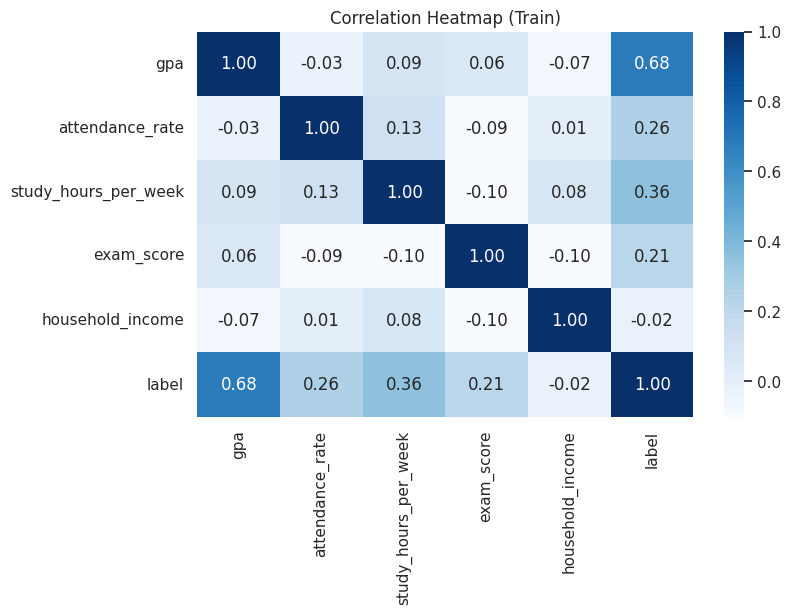

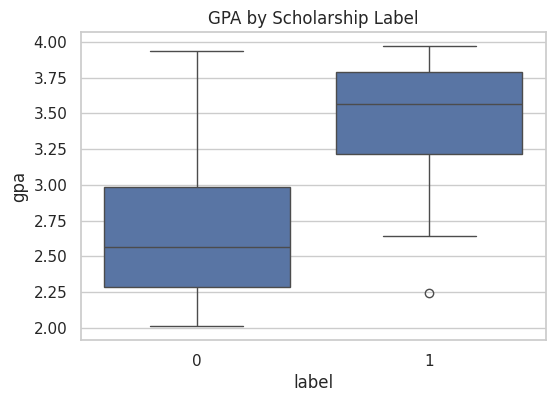

In [11]:
print('--- Train Info ---')
print(train_df.info())
print('\n--- Descriptive Statistics ---')
print(train_df.describe())
print('\nMissing values (train):')
print(train_df.isnull().sum())
print('\nMissing values (dev):')
print(dev_df.isnull().sum())
print('\nClass balance (train):')
print(train_df['label'].value_counts())
print(train_df['label'].value_counts(normalize=True).rename('ratio'))

dup_train = train_df.duplicated().sum()
dup_dev = dev_df.duplicated().sum()
print(f'\nDuplicate rows -> train: {dup_train}, dev: {dup_dev}')

def iqr_outlier_counts(df, cols):
    out = {}
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        is_outlier = (df[c] < low) | (df[c] > high)
        out[c] = int(is_outlier.sum())
    return out

outlier_summary = iqr_outlier_counts(train_df, FEATURE_COLS)
print('Potential outliers per feature (IQR rule, train):', outlier_summary)

# Visualize feature correlations
plt.figure(figsize=(8, 5))
correlation_matrix = train_df[FEATURE_COLS + ['label']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap (Train)')
plt.show()

# Check if GPA differs between scholarship groups
plt.figure(figsize=(6, 4))
sns.boxplot(data=train_df, x='label', y='gpa')
plt.title('GPA by Scholarship Label')
plt.show()

### EDA data quality interpretation

- Missing values are absent in both train and dev splits.
- Duplicate-row counts are reported above for both splits.
- Outlier counts are summarized with the IQR rule to flag potential extreme values per feature.
- Class distribution is shown to assess imbalance risk before modeling.


### 4.2 Data Preprocessing

This section applies from-scratch preprocessing (missing/categorical checks, scaling) with leakage prevention.


### Preprocessing decisions and justifications

1. **Missing values**: We explicitly check totals; if none exist, no imputation is applied.
2. **Categorical encoding**: We explicitly check for categorical feature columns; if none exist, encoding is not required.
3. **Scaling**: Standardization is used so features on different numeric ranges contribute comparably.
4. **Leakage prevention**: The scaler is fit only on training features, then reused to transform dev/hidden sets.


In [12]:
class StandardScaler:
    def __init__(self, eps=1e-8):
        self.mean_ = None
        self.std_ = None
        self.eps = eps  # prevent division by zero

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        assert self.mean_ is not None and self.std_ is not None, 'Scaler not fitted.'
        return (X - self.mean_) / (self.std_ + self.eps)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

# Check for missing values
missing_train_total = int(train_df[FEATURE_COLS + ['label']].isnull().sum().sum())
missing_dev_total = int(dev_df[FEATURE_COLS + ['label']].isnull().sum().sum())
print(f'Missing totals -> train: {missing_train_total}, dev: {missing_dev_total}')
if missing_train_total == 0 and missing_dev_total == 0:
    print('No imputation needed.')

# Check for categorical features
categorical_cols = train_df[FEATURE_COLS].select_dtypes(include=['object','category']).columns.tolist()
print('Categorical feature columns:', categorical_cols)
if len(categorical_cols) == 0:
    print('No categorical encoding required.')

X_train = train_df[FEATURE_COLS].to_numpy(dtype=float)
y_train = train_df['label'].to_numpy(dtype=int)

X_dev = dev_df[FEATURE_COLS].to_numpy(dtype=float)
y_dev = dev_df['label'].to_numpy(dtype=int)

# Fit scaler on training data only to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
print('Scaled shapes:', X_train_scaled.shape, X_dev_scaled.shape)

Missing totals -> train: 0, dev: 0
No imputation needed.
Categorical feature columns: []
No categorical encoding required.
Scaled shapes: (200, 5) (80, 5)


### 4.3 Model Training

This section defines and trains from-scratch models: Logistic Regression, Decision Tree, Random Forest, and Linear SVM.


### Alignment note

To better match the midterm handout examples, the second model is implemented as a **from-scratch Decision Tree** (alongside from-scratch Logistic Regression).


### Training-model implementations (beginner-friendly)

- Each model is implemented from scratch with readable step-by-step logic.
- We avoid compact matrix shorthand (such as `@`) and use explicit `np.dot(...)`.
- Models trained: Logistic Regression, Decision Tree, Random Forest, Linear SVM.


In [13]:
# =========================
# Model 1: Logistic Regression
# =========================
class LogisticRegression:
    def __init__(self, learning_rate=0.05, n_iterations=5000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0

    def _sigmoid(self, values):
        values = np.clip(values, -500, 500)
        return 1.0 / (1.0 + np.exp(-values))

    def fit(self, features, labels):
        n_samples, n_features = features.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.n_iterations):
            scores = np.dot(features, self.weights) + self.bias
            probs = self._sigmoid(scores)
            errors = probs - labels
            grad_w = np.dot(features.T, errors) / n_samples
            grad_b = np.mean(errors)
            self.weights = self.weights - self.learning_rate * grad_w
            self.bias = self.bias - self.learning_rate * grad_b
        return self

    def predict_proba(self, features):
        scores = np.dot(features, self.weights) + self.bias
        return self._sigmoid(scores)

    def predict(self, features, threshold=0.5):
        probs = self.predict_proba(features)
        return (probs >= threshold).astype(int)


# =========================
# Model 2: Decision Tree
# =========================
class DecisionTree:
    def __init__(self, max_depth=4, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, labels):
        if len(labels) == 0:
            return 0.0
        p_one = np.mean(labels)
        return 1.0 - p_one * p_one - (1.0 - p_one) * (1.0 - p_one)

    def _best_split(self, features, labels):
        n_samples = len(labels)
        parent_gini = self._gini(labels)
        best_gain, best_split = 0.0, None
        for feature_idx in range(features.shape[1]):
            thresholds = np.unique(features[:, feature_idx])
            for threshold in thresholds:
                left_mask = features[:, feature_idx] <= threshold
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                left_gini = self._gini(labels[left_mask])
                right_gini = self._gini(labels[right_mask])
                weighted = (left_mask.sum() / n_samples) * left_gini + (right_mask.sum() / n_samples) * right_gini
                gain = parent_gini - weighted
                if gain > best_gain:
                    best_gain = gain
                    best_split = (feature_idx, threshold, left_mask, right_mask)
        return best_split, best_gain

    def _build_tree(self, features, labels, depth):
        # The most frequent class in current node
        majority = int(np.mean(labels) >= 0.5)

        # Check stopping criteria: max depth, too few samples, or node is pure
        should_stop = (
            depth >= self.max_depth
            or len(labels) < self.min_samples_split
            or self._gini(labels) == 0.0
        )

        if should_stop:
            return {'leaf': True, 'prediction': majority}

        # Find the best feature and threshold to split on
        split, gain = self._best_split(features, labels)

        if split is None or gain <= 0:
            return {'leaf': True, 'prediction': majority}

        feature_idx, threshold, left_mask, right_mask = split

        # Recursively build left and right subtrees
        return {
            'leaf': False,
            'feature_idx': feature_idx,
            'threshold': threshold,
            'left': self._build_tree(features[left_mask], labels[left_mask], depth + 1),
            'right': self._build_tree(features[right_mask], labels[right_mask], depth + 1)
        }

    def fit(self, features, labels):
        self.tree = self._build_tree(features, labels, depth=0)
        return self

    def _predict_one(self, row, node):
        while not node['leaf']:
            node = node['left'] if row[node['feature_idx']] <= node['threshold'] else node['right']
        return node['prediction']

    def predict(self, features):
        return np.array([self._predict_one(row, self.tree) for row in features], dtype=int)


# =========================
# Model 3: Random Forest
# =========================
class RandomForest:
    def __init__(self, n_estimators=7, max_depth=4, min_samples_split=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.trees = []

    def fit(self, features, labels):
        rng = np.random.RandomState(self.random_state)
        n_samples = features.shape[0]
        self.trees = []
        for _ in range(self.n_estimators):
            idx = rng.choice(n_samples, size=n_samples, replace=True)
            x_boot = features[idx]
            y_boot = labels[idx]
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(x_boot, y_boot)
            self.trees.append(tree)
        return self

    def predict(self, features):
        preds = np.array([tree.predict(features) for tree in self.trees])
        vote_mean = np.mean(preds, axis=0)
        return (vote_mean >= 0.5).astype(int)


# =========================
# Model 4: Linear SVM
# =========================
class LinearSVM:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iterations=2000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0

    def fit(self, features, labels):
        # Convert labels from 0/1 to -1/1 for SVM math
        y_signed = np.where(labels == 1, 1, -1)
        n_samples, n_features = features.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Stochastic Gradient Descent (SGD)
        for _ in range(self.n_iterations):
            for i in range(n_samples):
                x_i = features[i]
                margin = y_signed[i] * (np.dot(x_i, self.weights) + self.bias)

                # If correctly classified with enough margin, only apply penalty to weights
                if margin >= 1:
                    grad_w = 2 * self.lambda_param * self.weights
                    self.weights = self.weights - self.learning_rate * grad_w
                # Otherwise, update weights and bias based on the error
                else:
                    grad_w = 2 * self.lambda_param * self.weights - y_signed[i] * x_i
                    grad_b = -y_signed[i]

                    self.weights = self.weights - self.learning_rate * grad_w
                    self.bias = self.bias - self.learning_rate * grad_b

        return self

    def decision_function(self, features):
        return np.dot(features, self.weights) + self.bias

    def predict(self, features):
        scores = self.decision_function(features)
        return (scores >= 0).astype(int)


### 4.4 Model Evaluation

This section computes manual metrics (accuracy, precision, recall, F1), compares models, and selects the best model.


### Metric computation and model selection logic

- Metrics are computed manually from TP/TN/FP/FN counts.
- We compare all models on dev set.
- Best model is selected by highest F1 score, then accuracy as tie-breaker.


In [14]:
def confusion_counts(y_true, y_pred):
    true_pos = int(np.sum((y_true == 1) & (y_pred == 1)))
    true_neg = int(np.sum((y_true == 0) & (y_pred == 0)))
    false_pos = int(np.sum((y_true == 0) & (y_pred == 1)))
    false_neg = int(np.sum((y_true == 1) & (y_pred == 0)))
    return true_pos, true_neg, false_pos, false_neg


def metrics_binary(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1_score,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}


# Split train set for hyperparameter validation
rng = np.random.RandomState(42)
idx = np.arange(len(X_train_scaled))
rng.shuffle(idx)
cut = int(0.8 * len(idx))
idx_tr = idx[:cut]
idx_val = idx[cut:]
X_tr = X_train_scaled[idx_tr]
y_tr = y_train[idx_tr]
X_val = X_train_scaled[idx_val]
y_val = y_train[idx_val]

# Hyperparameter grid for each model
candidate_space = {
    'Logistic Regression': [
        LogisticRegression(learning_rate=0.03, n_iterations=4000),
        LogisticRegression(learning_rate=0.05, n_iterations=5000),
        LogisticRegression(learning_rate=0.08, n_iterations=6000)
    ],
    'Decision Tree': [
        DecisionTree(max_depth=3, min_samples_split=5),
        DecisionTree(max_depth=4, min_samples_split=5),
        DecisionTree(max_depth=5, min_samples_split=8)
    ],
    'Random Forest': [
        RandomForest(n_estimators=7, max_depth=4, min_samples_split=5, random_state=42),
        RandomForest(n_estimators=11, max_depth=4, min_samples_split=5, random_state=42),
        RandomForest(n_estimators=15, max_depth=5, min_samples_split=6, random_state=42)
    ],
    'Linear SVM': [
        LinearSVM(learning_rate=0.01, lambda_param=0.01, n_iterations=2000),
        LinearSVM(learning_rate=0.005, lambda_param=0.02, n_iterations=2500),
        LinearSVM(learning_rate=0.01, lambda_param=0.005, n_iterations=2500)
    ]
}


def predict_with_threshold(model_name, model_obj, features, threshold):
    if model_name == 'Logistic Regression':
        probs = model_obj.predict_proba(features)
        return (probs >= threshold).astype(int)
    if model_name == 'Linear SVM':
        scores = model_obj.decision_function(features)
        return (scores >= threshold).astype(int)
    return model_obj.predict(features)


selected_models = {}
selected_thresholds = {}
for model_name, model_list in candidate_space.items():
    best_val_f1 = -1.0
    best_val_acc = -1.0
    best_model_cfg = None
    best_threshold = 0.5 if model_name == 'Logistic Regression' else 0.0

    for model_obj in model_list:
        model_obj.fit(X_tr, y_tr)
        if model_name in ['Logistic Regression', 'Linear SVM']:
            thresholds = [0.35, 0.45, 0.5, 0.55, 0.65] if model_name.startswith('Logistic') else [-0.5, -0.2, 0.0, 0.2, 0.5]
            for thr in thresholds:
                val_pred = predict_with_threshold(model_name, model_obj, X_val, thr)
                val_metrics = metrics_binary(y_val, val_pred)
                if (val_metrics['f1'] > best_val_f1) or (val_metrics['f1'] == best_val_f1 and val_metrics['accuracy'] > best_val_acc):
                    best_val_f1 = val_metrics['f1']
                    best_val_acc = val_metrics['accuracy']
                    best_model_cfg = model_obj
                    best_threshold = thr
        else:
            val_pred = model_obj.predict(X_val)
            val_metrics = metrics_binary(y_val, val_pred)
            if (val_metrics['f1'] > best_val_f1) or (val_metrics['f1'] == best_val_f1 and val_metrics['accuracy'] > best_val_acc):
                best_val_f1 = val_metrics['f1']
                best_val_acc = val_metrics['accuracy']
                best_model_cfg = model_obj

    # Refit on full training data
    best_model_cfg.fit(X_train_scaled, y_train)
    selected_models[model_name] = best_model_cfg
    selected_thresholds[model_name] = best_threshold


results = []
preds = {}
for model_name, model_obj in selected_models.items():
    dev_predictions = predict_with_threshold(model_name, model_obj, X_dev_scaled, selected_thresholds[model_name])
    preds[model_name] = dev_predictions
    metric_row = {'model': model_name, 'selected_threshold': selected_thresholds[model_name]}
    metric_row.update(metrics_binary(y_dev, dev_predictions))
    results.append(metric_row)

results_df = pd.DataFrame(results).sort_values(by=['f1', 'accuracy'], ascending=False).reset_index(drop=True)
print(results_df[['model', 'selected_threshold', 'accuracy', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn']])

best_model_name = results_df.loc[0, 'model']
best_model = selected_models[best_model_name]
best_threshold = selected_thresholds[best_model_name]
print('Best model selected:', best_model_name)
print('Best threshold selected:', best_threshold)




                 model  selected_threshold  accuracy  precision   recall  \
0  Logistic Regression                0.45    0.9750   0.941176  1.00000   
1           Linear SVM               -0.20    0.9625   0.914286  1.00000   
2        Random Forest                0.00    0.9000   0.852941  0.90625   
3        Decision Tree                0.00    0.8250   0.725000  0.90625   

         f1  tp  tn  fp  fn  
0  0.969697  32  46   2   0  
1  0.955224  32  45   3   0  
2  0.878788  29  43   5   3  
3  0.805556  29  37  11   3  
Best model selected: Logistic Regression
Best threshold selected: 0.45


### 4.5 Error Analysis

This section investigates misclassifications, confusion counts, and likely causes of model mistakes.


Total dev rows: 80
Total errors: 2
    id   gpa  attendance_rate  study_hours_per_week  exam_score  \
17  18  2.91             0.77                    21          96   
66  67  3.58             0.94                     6          73   

    household_income  label  label_pred  is_correct  
17              1742      0           1       False  
66              1673      0           1       False  
Confusion counts -> TP:32, TN:46, FP:2, FN:0


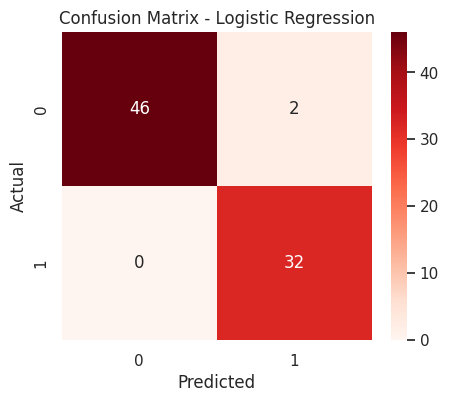

Mean feature values (misclassified):
gpa                        3.245
attendance_rate            0.855
study_hours_per_week      13.500
exam_score                84.500
household_income        1707.500
dtype: float64
Mean feature values (correctly classified):
gpa                        2.994103
attendance_rate            0.813974
study_hours_per_week      20.038462
exam_score                76.307692
household_income        1103.141026
dtype: float64


In [15]:
best_dev_pred = preds[best_model_name]
analysis_df = dev_df.copy()
analysis_df['label_pred'] = best_dev_pred
analysis_df['is_correct'] = (analysis_df['label'] == analysis_df['label_pred'])
errors_df = analysis_df[~analysis_df['is_correct']]

print('Total dev rows:', len(analysis_df))
print('Total errors:', len(errors_df))
print(errors_df)

tp, tn, fp, fn = confusion_counts(y_dev, best_dev_pred)
print(f'Confusion counts -> TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}')

cm = pd.crosstab(pd.Series(y_dev, name='Actual'), pd.Series(best_dev_pred, name='Predicted'))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

correct_df = analysis_df[analysis_df['is_correct']]
print('Mean feature values (misclassified):')
print(errors_df[FEATURE_COLS].mean(numeric_only=True))

print('Mean feature values (correctly classified):')
print(correct_df[FEATURE_COLS].mean(numeric_only=True))


### Error analysis interpretation

- FP/FN counts are reported explicitly from confusion-count outputs.
- Misclassified vs correctly classified feature means are compared to identify pattern shifts.
- Likely causes include borderline cases near the decision threshold and limited expressiveness of simple decision boundaries.


## 5.0 Hidden Test Prediction and Submission File

This section generates hidden-test predictions and writes the required `predictions.csv` file.


In [16]:
# Load and prepare hidden test data
hidden_df = pd.read_csv(HIDDEN_PATH)
X_hidden = hidden_df[FEATURE_COLS].to_numpy(dtype=float)
X_hidden_scaled = scaler.transform(X_hidden)

# Generate predictions
hidden_pred = predict_with_threshold(best_model_name, best_model, X_hidden_scaled, best_threshold)

# Create submission file
submission = pd.DataFrame({
    'id': hidden_df['id'],
    'label_pred': hidden_pred
})

# Quick validation
print(f'Generated {len(submission)} predictions')
print(f'Distribution: {submission["label_pred"].value_counts().to_dict()}')

submission.to_csv('predictions.csv', index=False)
print('Saved predictions.csv')
print(submission.head())

Generated 100 predictions
Distribution: {0: 61, 1: 39}
Saved predictions.csv
     id  label_pred
0  1001           1
1  1002           1
2  1003           0
3  1004           0
4  1005           1


In [26]:
hidden_labeled = pd.read_csv(HIDDEN_PATH)
pred_df = pd.read_csv("predictions.csv")

check_df = hidden_labeled.merge(pred_df, on="id", how="left")
hidden_accuracy = (check_df["label"] == check_df["label_pred"]).mean()

print(f"Hidden accuracy: {hidden_accuracy:.4f} ({hidden_accuracy * 100:.2f}%)")
print("Correct:", int((check_df["label"] == check_df["label_pred"]).sum()))
print("Total:", len(check_df))

tp, tn, fp, fn = confusion_counts(
    check_df["label"].to_numpy(),
    check_df["label_pred"].to_numpy()
)
print(f"TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}")


Hidden accuracy: 0.8300 (83.00%)
Correct: 83
Total: 100
TP:31, TN:52, FP:8, FN:9


## 6.0 Conclusion and Final Summary

This section summarizes best model selection and key development-set findings.
